In [107]:
# library for feature engineering and EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from IPython.display import Image
from datetime import datetime
import random
import pandas_profiling

# library for statistic
from scipy import stats
from scipy.stats import skew
from scipy.stats import kurtosis


# library for machine learning
from sklearn.cluster import KMeans

%matplotlib inline

In [108]:
import pandas as pd
# Reorder columns as requested (note: fixed typos in column names)
df = pd.read_csv('data/data.csv')
df

,Unnamed: 0,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,42912469,2019-11-17 12:55:27 UTC,view,1801940,2053013554415534427,electronics.video.tv,haier,231.64,557260014,9eae31f2-7728-4a63-8ec1-214fa7b1a913
1,33404333,2019-11-16 04:44:35 UTC,view,100003663,2053013557133443581,furniture.living_room.cabinet,stendmebel,430.87,532931161,356b963b-ac2a-43cc-9ad2-c9f5eaadcb60
2,28620112,2019-11-15 08:43:53 UTC,view,1004249,2053013555631882655,electronics.smartphone,apple,739.04,550988096,aa13bf9c-1e22-405d-a5f0-3803ffe546c8
3,8744840,2019-11-06 10:21:52 UTC,view,3701134,2053013565983425517,appliances.environment.vacuum,bosch,115.81,560410260,97b64f35-ee84-4732-bfc9-78a1b4bc1426
4,58422604,2019-11-25 15:12:34 UTC,view,1004505,2053013555631882655,electronics.smartphone,xiaomi,514.56,516687754,8f147c20-c958-49b9-a391-c27eecf56fb0
...,...,...,...,...,...,...,...,...,...,...
6750193,33128661,2019-11-16 03:39:18 UTC,cart,3600997,2053013563810775923,appliances.kitchen.washer,indesit,282.86,518663013,b5bc287a-5013-49ba-81cc-3f1449167e83
6750194,54106540,2019-11-22 19:42:54 UTC,view,1004757,2053013555631882655,electronics.smartphone,meizu,87.21,500944450,2ab159da-c169-4573-9ff0-d21b3ee4d578
6750195,66706783,2019-11-30 13:01:57 UTC,view,22900023,2053013561780732677,furniture.bedroom.pillow,NaN,56.63,515637063,7a8a93d5-c18c-419b-a974-f883cc522ec0
6750196,8017227,2019-11-05 19:48:51 UTC,view,5701120,2053013553970938175,auto.accessories.player,pioneer,77.22,513595940,e503b90b-350a-4c7d-ac2f-e9a53a9dd745


In [109]:
df = df[['user_id', 'event_type', 'brand', 'category_code', "category_id", "product_id", 'price', 'event_time', 'user_session', 'Unnamed: 0']]
df.drop(columns=['Unnamed: 0'], inplace=True)
# Not sure what is Unnamed:0 -> We may need drop it later
# event time including date and time.
# event_type shows only view. 

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_17544\3132441981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Unnamed: 0'], inplace=True)


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6750198 entries, 0 to 6750197
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        int64  
 1   event_type     object 
 2   brand          object 
 3   category_code  object 
 4   category_id    int64  
 5   product_id     int64  
 6   price          float64
 7   event_time     object 
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 463.5+ MB


In [111]:
for column_name in df.columns:
    print(column_name, df[column_name].dtype, df[column_name].unique(), df[column_name].nunique())

user_id int64 [557260014 532931161 550988096 ... 540648964 516187585 577991311] 1830972
event_type object ['view' 'cart' 'purchase'] 3
brand object ['haier' 'stendmebel' 'apple' ... 'tutu' 'constancy' 'worldpeacekeepers'] 3911
category_code object ['electronics.video.tv' 'furniture.living_room.cabinet'
 'electronics.smartphone' 'appliances.environment.vacuum'
 'appliances.iron' 'electronics.audio.acoustic'
 'appliances.kitchen.microwave' nan 'electronics.telephone'
 'auto.accessories.compressor' 'computers.notebook'
 'appliances.kitchen.refrigerators' 'electronics.audio.headphone'
 'appliances.kitchen.oven' 'computers.peripherals.printer'
 'accessories.wallet' 'appliances.kitchen.dishwasher'
 'furniture.bedroom.bed' 'apparel.shoes.keds' 'appliances.kitchen.blender'
 'electronics.clocks' 'construction.tools.saw' 'apparel.shoes'
 'electronics.camera.video' 'appliances.environment.water_heater'
 'computers.components.cooler' 'kids.carriage' 'auto.accessories.alarm'
 'construction.tools.we

In [112]:
list_casting_as_object = ["product_id", "category_id", "user_id"]
for column_name in list_casting_as_object:
    df[column_name] = df[column_name].astype("object")

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_17544\1623975936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].astype("object")
C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_17544\1623975936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].astype("object")
C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_17544\1623975936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6750198 entries, 0 to 6750197
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        object 
 1   event_type     object 
 2   brand          object 
 3   category_code  object 
 4   category_id    object 
 5   product_id     object 
 6   price          float64
 7   event_time     object 
 8   user_session   object 
dtypes: float64(1), object(8)
memory usage: 463.5+ MB


In [114]:
list_categorical_columns = list(df.select_dtypes(include=['string','object']).columns)
list_numeric_columns = list(df.select_dtypes(include=['float64']).columns)
target_column = "shares"
print(len(df.columns))
print(len(list_categorical_columns))
print(len(list_numeric_columns))

9
8
1


In [116]:
df.isnull().sum()

user_id                0
event_type             0
brand             923540
category_code    2190762
category_id            0
product_id             0
price                  0
event_time             0
user_session           0
dtype: int64

In [117]:
df[list_categorical_columns].nunique().sort_values() 

event_type             3
category_code        127
category_id          674
brand               3911
product_id        149323
user_id          1830972
event_time       2022083
user_session     4246753
dtype: int64

In [118]:
column_removed = ["category_id", "brand", "product_id", "event_time", "user_session"]
df = df.drop(column_removed, axis=1)

In [119]:
for column in column_removed:
    list_categorical_columns.remove(column)

In [120]:
df = df[df["event_type"] == "purchase"]

In [121]:
display(df)

,user_id,event_type,category_code,price
199,561394679,purchase,NaN,100.39
471,530510565,purchase,electronics.smartphone,255.57
487,567695354,purchase,NaN,85.71
651,563648409,purchase,electronics.smartphone,88.26
653,560198101,purchase,electronics.smartphone,1029.09
...,...,...,...,...
6749591,575990174,purchase,electronics.audio.headphone,25.69
6749761,572523941,purchase,NaN,36.04
6749798,550413435,purchase,electronics.smartphone,104.93
6749829,575871876,purchase,appliances.kitchen.juicer,128.68


In [122]:
df.isna().sum()

user_id              0
event_type           0
category_code    23474
price                0
dtype: int64

In [ ]:
# Drop rows with Nan values -> category code
df_filtered = df.dropna().reset_index(drop=True)

In [ ]:
# Split category_code into two new columns: category_code_1st and category_code_2nd
df_filtered["category_code_1st"] = df_filtered["category_code"].apply(lambda x : x.split(".")[0])
df_filtered["category_code_2nd"] = df_filtered["category_code"].apply(lambda x : x.split(".")[1])

In [125]:
df_filtered.nunique()

user_id              57292
event_type               1
category_code          120
price                 8770
category_code_1st       13
category_code_2nd       54
dtype: int64

<Axes: xlabel='category_code', ylabel='Count'>

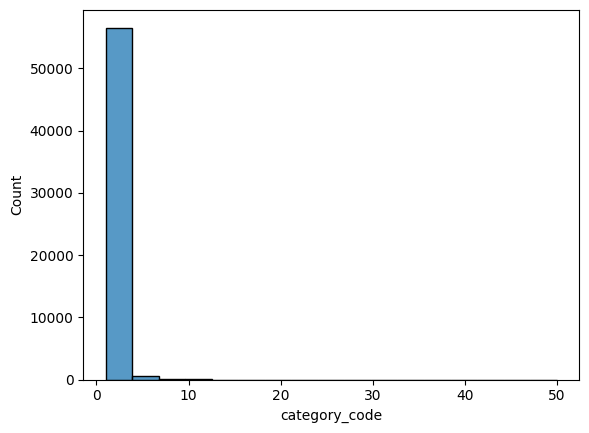

In [126]:
sns.histplot(df_filtered.groupby("user_id").count()["category_code"])

In [127]:
display(df_filtered)

,user_id,event_type,category_code,price,category_code_1st,category_code_2nd
0,530510565,purchase,electronics.smartphone,255.57,electronics,smartphone
1,563648409,purchase,electronics.smartphone,88.26,electronics,smartphone
2,560198101,purchase,electronics.smartphone,1029.09,electronics,smartphone
3,572466923,purchase,electronics.video.tv,694.17,electronics,video
4,547251428,purchase,electronics.smartphone,179.16,electronics,smartphone
...,...,...,...,...,...,...
68068,572142479,purchase,electronics.smartphone,136.71,electronics,smartphone
68069,575990174,purchase,electronics.audio.headphone,25.69,electronics,audio
68070,550413435,purchase,electronics.smartphone,104.93,electronics,smartphone
68071,575871876,purchase,appliances.kitchen.juicer,128.68,appliances,kitchen


In [128]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68073 entries, 0 to 68072
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            68073 non-null  object 
 1   event_type         68073 non-null  object 
 2   category_code      68073 non-null  object 
 3   price              68073 non-null  float64
 4   category_code_1st  68073 non-null  object 
 5   category_code_2nd  68073 non-null  object 
dtypes: float64(1), object(5)
memory usage: 3.1+ MB


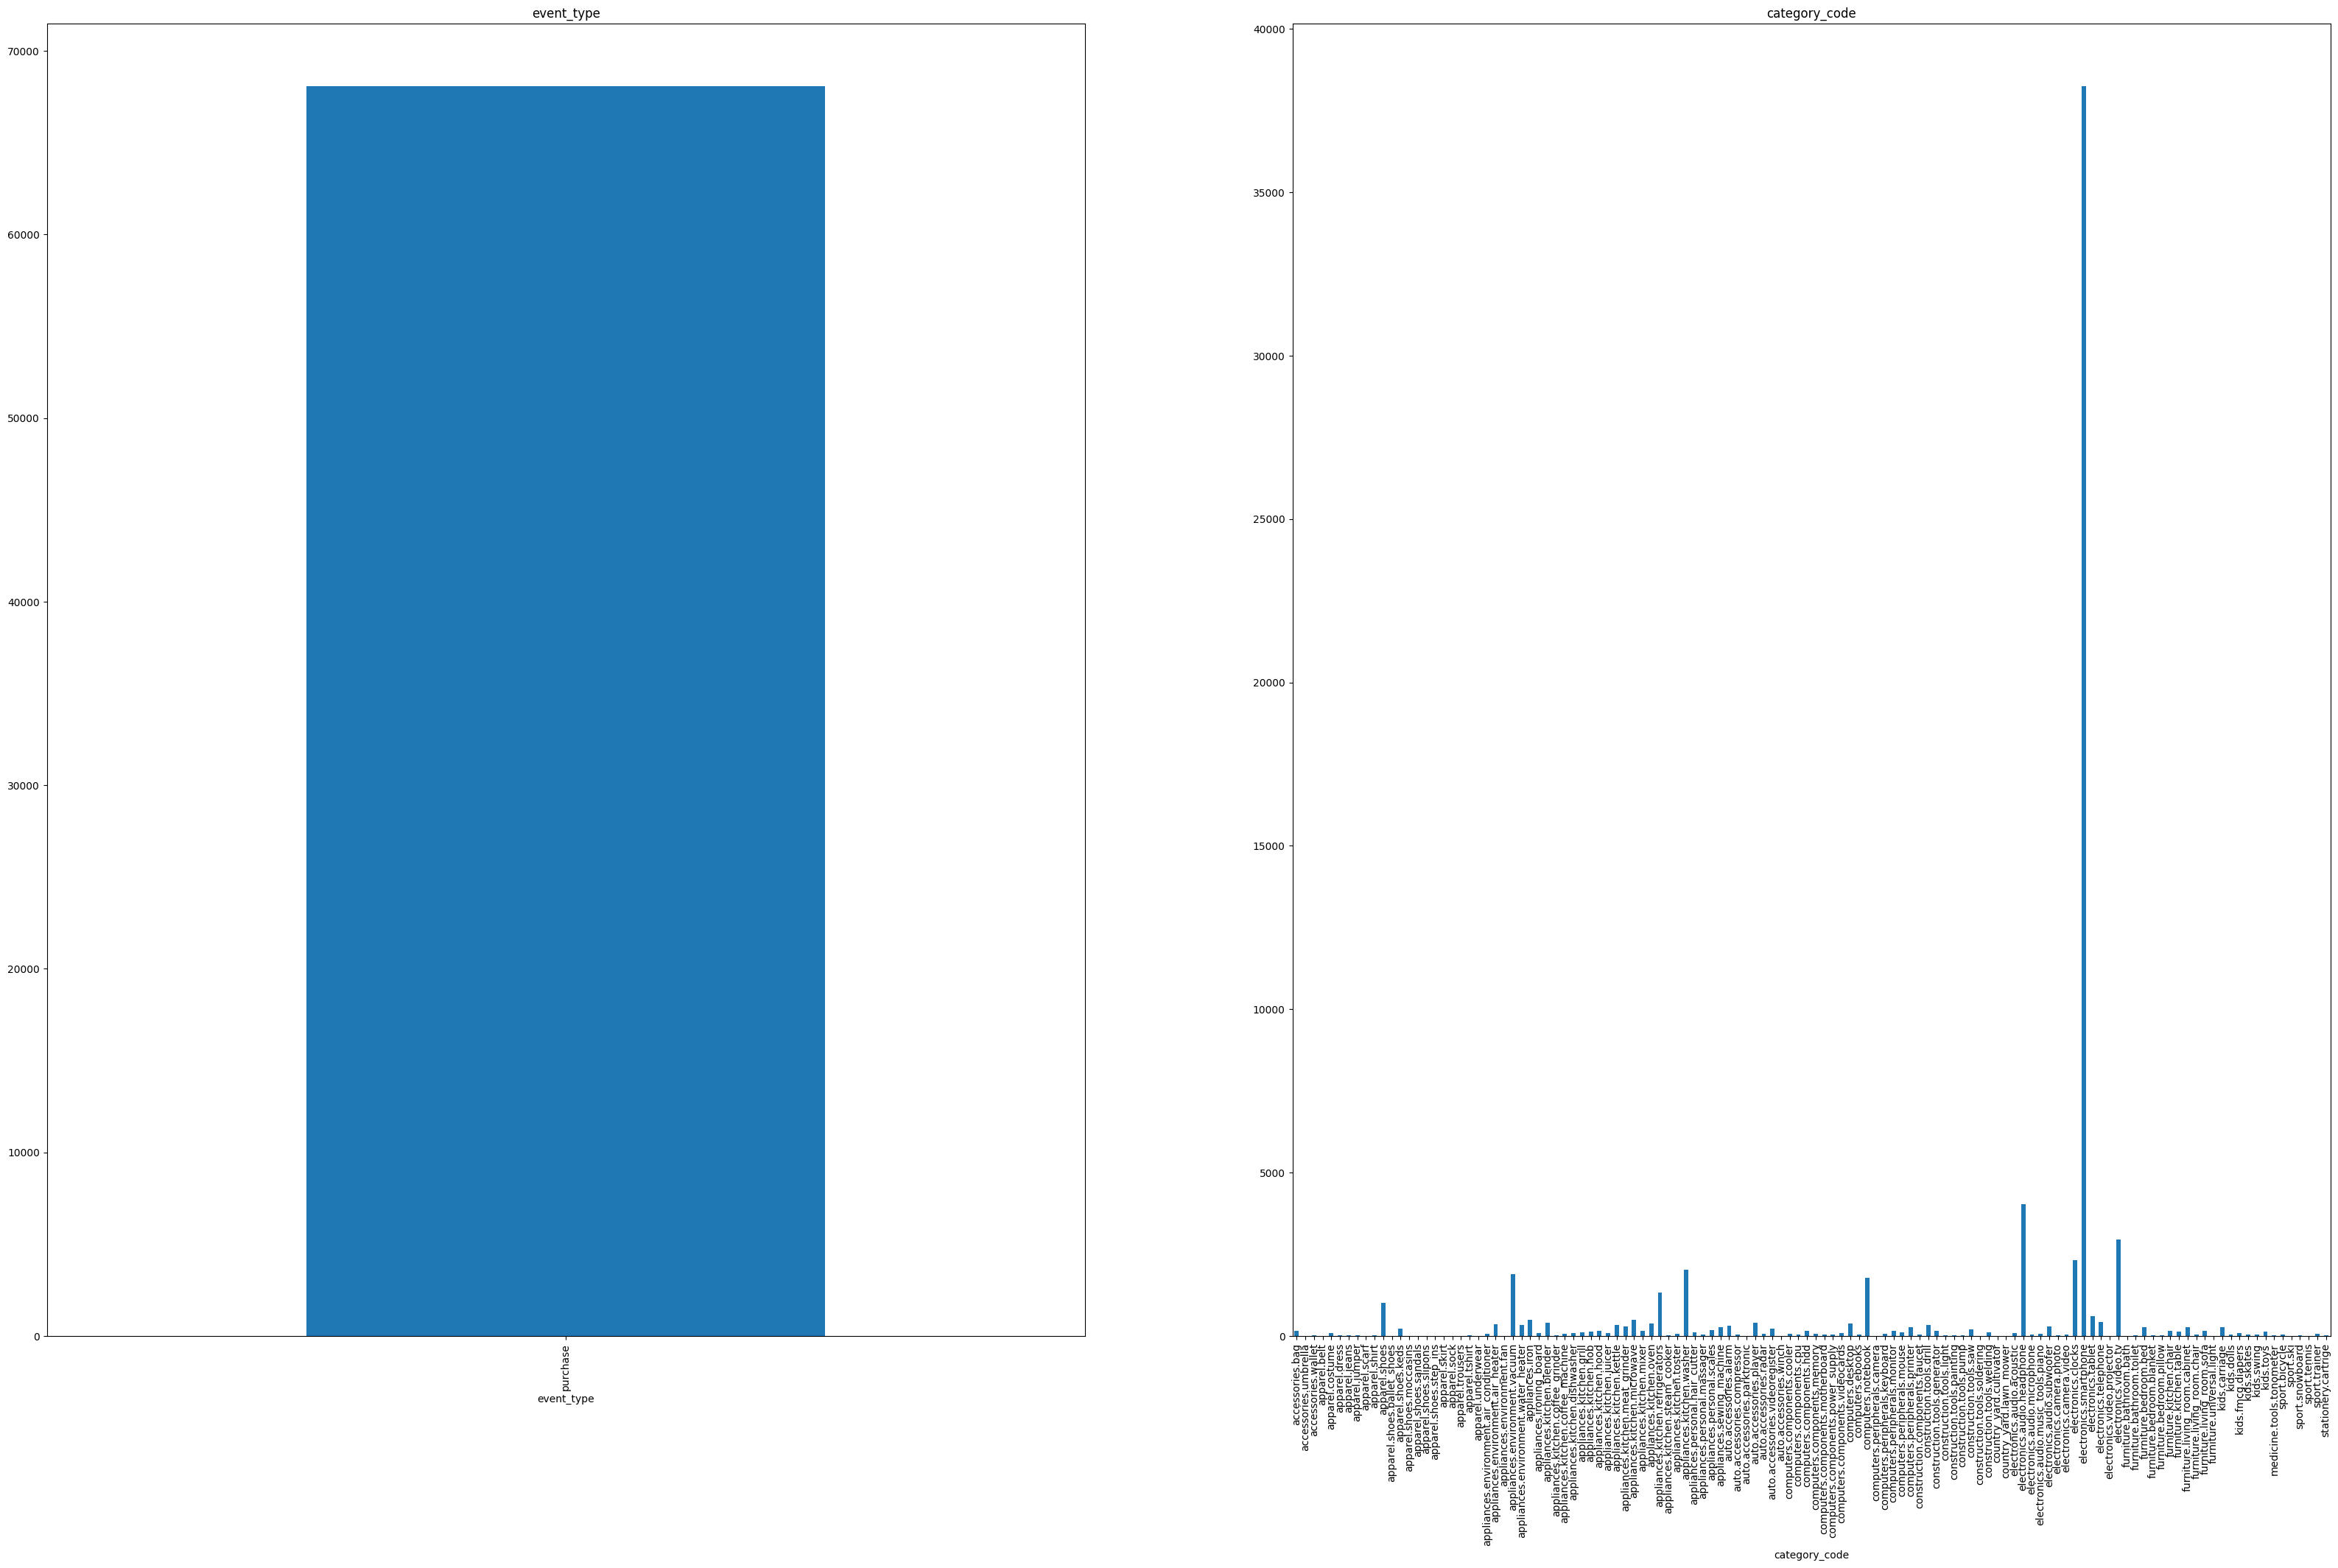

In [129]:
# cateogircla column 별 분포 확인 
plt.figure(figsize=(40,40))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.2)
for column_name in list_categorical_columns:
    if column_name == "user_id":
        continue
    plt.subplot(2,2,x)
    x = x+1
    df_filtered[column_name].value_counts().sort_index().plot(kind='bar')
    plt.title(column_name)
plt.show()

In [130]:
df[list_numeric_columns].nunique().sort_values()

price    11584
dtype: int64

In [131]:
df["price"].describe()

count    91547.000000
mean       300.111189
std        341.639659
min          0.870000
25%         82.840000
50%        169.920000
75%        362.100000
max       2574.070000
Name: price, dtype: float64

<Axes: >

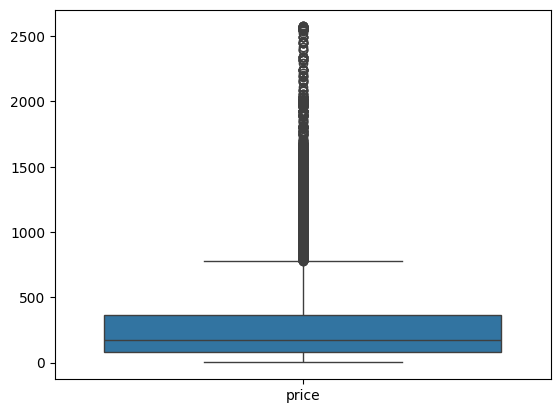

In [132]:
sns.boxplot(df[list_numeric_columns])

In [133]:
# skew-> 1 or -1, kurtosis -> 3

for column_name in list_numeric_columns:
  print(column_name, "skew : ", skew(df[column_name]), "kur : ", kurtosis(df[column_name]) )
  
# 추후 scaling을 활용한 feature preprocessing의 필요성 확인

price skew :  2.1110804586090732 kur :  4.943002067732956


In [135]:
df_filtered.profile_report().to_file("data" + "data_eda_with_pandasprofiling.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\TaeyoonKim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ydata_profiling\model\pandas\summary_pandas.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series = series.fillna(np.nan)


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [136]:
df_filtered.isna().sum().sort_values(ascending=False)

user_id              0
event_type           0
category_code        0
price                0
category_code_1st    0
category_code_2nd    0
dtype: int64

In [138]:
df_filtered

,user_id,event_type,category_code,price,category_code_1st,category_code_2nd
0,530510565,purchase,electronics.smartphone,255.57,electronics,smartphone
1,563648409,purchase,electronics.smartphone,88.26,electronics,smartphone
2,560198101,purchase,electronics.smartphone,1029.09,electronics,smartphone
3,572466923,purchase,electronics.video.tv,694.17,electronics,video
4,547251428,purchase,electronics.smartphone,179.16,electronics,smartphone
...,...,...,...,...,...,...
68068,572142479,purchase,electronics.smartphone,136.71,electronics,smartphone
68069,575990174,purchase,electronics.audio.headphone,25.69,electronics,audio
68070,550413435,purchase,electronics.smartphone,104.93,electronics,smartphone
68071,575871876,purchase,appliances.kitchen.juicer,128.68,appliances,kitchen


In [139]:
df_filtered_pivot = df_filtered.pivot_table(index=df_filtered.index, columns='category_code_1st', values=["price", "price"], aggfunc=["first","count"]).fillna(0)

In [140]:
df_filtered_pivot.columns = ['_'.join(col) for col in df_filtered_pivot.columns.values]

In [141]:
df_filtered_pivot["user_id"] = df_filtered["user_id"]

In [142]:
df_filtered_pivot.head(2)

,first_price_accessories,first_price_apparel,first_price_appliances,first_price_auto,first_price_computers,first_price_construction,first_price_country_yard,first_price_electronics,first_price_furniture,first_price_kids,...,count_price_computers,count_price_construction,count_price_country_yard,count_price_electronics,count_price_furniture,count_price_kids,count_price_medicine,count_price_sport,count_price_stationery,user_id
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,255.57,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,530510565
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.26,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,563648409


In [146]:
df_user_pivot = df_filtered_pivot.groupby("user_id").agg(sum)

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_17544\897717783.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_user_pivot = df_filtered_pivot.groupby("user_id").agg(sum)


In [147]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_user_pivot.loc[:, :] = scaler.fit_transform(df_user_pivot)
df_user_pivot.head(1)

,first_price_accessories,first_price_apparel,first_price_appliances,first_price_auto,first_price_computers,first_price_construction,first_price_country_yard,first_price_electronics,first_price_furniture,first_price_kids,...,count_price_auto,count_price_computers,count_price_construction,count_price_country_yard,count_price_electronics,count_price_furniture,count_price_kids,count_price_medicine,count_price_sport,count_price_stationery
user_id,,,,,,,,,,,,,,,,,,,,,
225644257,0.0,0.0,0.0,0.0,0.002869,0.0,0.0,0.0,0.0,0.0,...,0.0,0.111111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [148]:
# title_sentiment_polarity 컬럼으로 실습 

x_min = df_user_pivot["first_price_computers"].min()
x_max = df_user_pivot["first_price_computers"].max()
print(x_min)
print(x_max)

first_price_computers    0.0
first_price_computers    0.0
dtype: float64
first_price_computers    1.0
first_price_computers    1.0
dtype: float64


In [149]:
(df_user_pivot["first_price_computers"] - x_min)/(x_max-x_min)

,first_price_computers,first_price_computers
user_id,,
225644257,0.002869,0.002869
315835876,0.000000,0.000000
435584787,0.000000,0.000000
448659331,0.000000,0.000000
465378521,0.000000,0.000000
...,...,...
579908999,0.000000,0.000000
579926563,0.000000,0.000000
579935169,0.000000,0.000000
